Epoch 1/20


C:\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5966 - loss: 1.4983 - val_accuracy: 0.7475 - val_loss: 0.8993
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7861 - loss: 0.7234 - val_accuracy: 0.8175 - val_loss: 0.6490
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8405 - loss: 0.5488 - val_accuracy: 0.8478 - val_loss: 0.5359
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8712 - loss: 0.4442 - val_accuracy: 0.8656 - val_loss: 0.4653
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8883 - loss: 0.3729 - val_accuracy: 0.8819 - val_loss: 0.3995
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9068 - loss: 0.3191 - val_accuracy: 0.8925 - val_loss: 0.3658
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9156 - loss: 0.2796 - val_accuracy: 0.9003 - val_loss: 0.3340
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9259 - loss: 0.2470 - val_accuracy: 0.9100 - val_

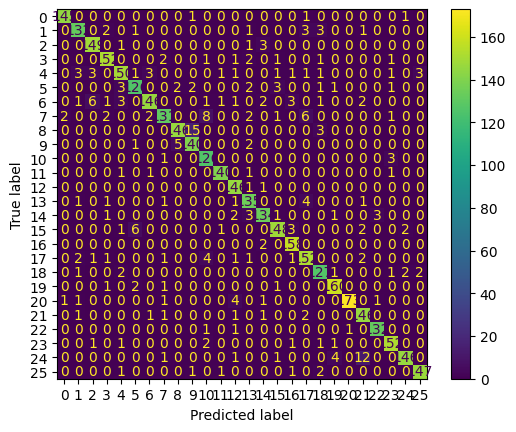

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_catego*ical

# 1. Load dataset
dataset = pd.read_csv("letter-recognition.data", header=None)

# 2. Split features and labels
X = dataset.iloc[:, 1:17].values
y = dataset.iloc[:, 0].values

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=10
)

# 5. Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 6. Build model
model = Sequential([
    Dense(128, activation='relu', input_shape=(16,)),
    Dense(64, activation='relu'),
    Dense(26, activation='softmax')
])

# 7. Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 8. Train model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# 9. Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

# -------------------------------------------------
# 🔥 SIMPLIFIED OUTPUT PART
# -------------------------------------------------

# 10. Predictions
pred_labels = np.argmax(model.predict(X_test), axis=1)
true_labels = np.argmax(y_test, axis=1)

# Convert to letters
pred_letters = encoder.inverse_transform(pred_labels)
true_letters = encoder.inverse_transform(true_labels)

# 11. Show sample predictions (simple)
print("\nSample Predictions:")
for i in range(5):
    print(pred_letters[i], "|", true_letters[i])

# 12. Confusion Matrix (simple)
cm = confusion_matrix(true_labels, pred_labels)
ConfusionMatrixDisplay(cm).plot()
plt.show()